<a href="https://colab.research.google.com/github/Abdullah-567/Deep-Learning-Tutorials/blob/main/Tutorial_no_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 — Import Required Libraries

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

STEP 2 — Load and Split the Dataset

In [ ]:
# Load the Iris dataset
iris = load_iris()

X = iris.data       # Features
y = iris.target     # Labels

# Split the data into training and testing sets
# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 105
Testing samples: 45


STEP 3 — Scale the Data

In [ ]:
# Standardize the features
scaler = StandardScaler()

# Fit on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

STEP 4 — Create and Train the MLP

In [ ]:
# Create an MLP classifier with two hidden layers
# Each hidden layer contains 10 neurons

mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    max_iter=1000,
    random_state=42,
    learning_rate_init=0.001
)

# Train the MLP classifier
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

STEP 5 — Make Predictions and Evaluate

In [ ]:
# Predict the test set
y_pred = mlp.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



STEP 6 — Display MLP Structure and Training Information

In [ ]:
# Display the structure of the MLP classifier

print("MLP Structure:")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Number of outputs: {mlp.n_outputs_}")
print(f"Activation function: {mlp.activation}")
print(f"Output activation function: {mlp.out_activation_}")
print(f"Number of epochs: {mlp.n_iter_}")

MLP Structure:
Number of layers: 4
Number of outputs: 3
Activation function: relu
Output activation function: softmax
Number of epochs: 609


STEP 7 — Plot the Learning Curve

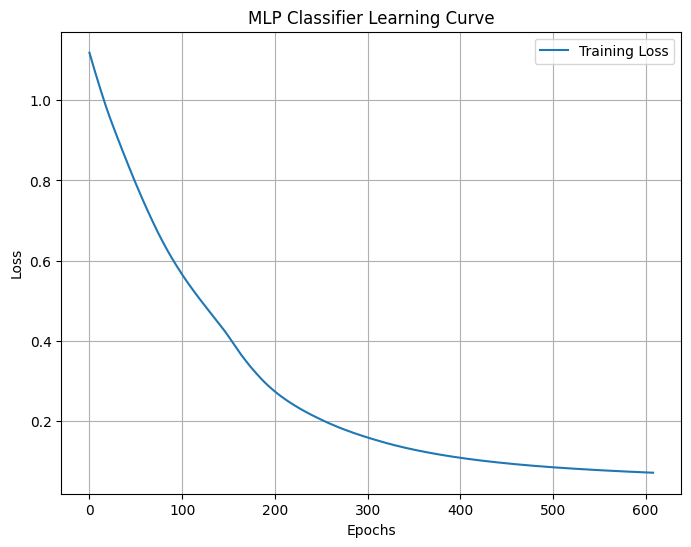

In [ ]:
# Plot the loss curve

plt.figure(figsize=(8, 6))

plt.plot(mlp.loss_curve_, label='Training Loss')

plt.title('MLP Classifier Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

TASK 1 — Different Hidden Layers and Neurons

Configuration	Hidden layers

Model 1 =	1 layer × 5 neurons

Model 2 =	1 layer × 10 neurons

Model 3 =	1 layer × 20 neurons

Model 4 =	2 layers × 10 neurons

Model 5 =	2 layers × 20 neurons

Model 6	= 3 layers × 10 neurons

In [ ]:
configurations = {
    "1 layer - 5 neurons": (5,),
    "1 layer - 10 neurons": (10,),
    "1 layer - 20 neurons": (20,),
    "2 layers - 10,10": (10, 10),
    "2 layers - 20,20": (20, 20),
    "3 layers - 10,10,10": (10, 10, 10)
}

Train All Configurations

In [ ]:
results = {}

for name, architecture in configurations.items():

    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        max_iter=1000,
        random_state=42,
        learning_rate_init=0.001
    )

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)

    accuracy_model = accuracy_score(y_test, y_pred_model)

    results[name] = {
        "model": model,
        "accuracy": accuracy_model,
        "epochs": model.n_iter_,
        "loss_curve": model.loss_curve_
    }

    print(name)
    print(f"Accuracy: {accuracy_model:.4f}")
    print(f"Epochs: {model.n_iter_}")
    print("-" * 40)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


1 layer - 5 neurons
Accuracy: 1.0000
Epochs: 1000
----------------------------------------


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


1 layer - 10 neurons
Accuracy: 1.0000
Epochs: 1000
----------------------------------------
1 layer - 20 neurons
Accuracy: 1.0000
Epochs: 744
----------------------------------------
2 layers - 10,10
Accuracy: 1.0000
Epochs: 609
----------------------------------------
2 layers - 20,20
Accuracy: 1.0000
Epochs: 526
----------------------------------------
3 layers - 10,10,10
Accuracy: 1.0000
Epochs: 857
----------------------------------------


Compare the Results

In [ ]:
print("FINAL COMPARISON")
print("=" * 60)

for name, result in results.items():

    print(
        f"{name:25} "
        f"Accuracy: {result['accuracy']:.4f}   "
        f"Epochs: {result['epochs']}"
    )

FINAL COMPARISON
1 layer - 5 neurons       Accuracy: 1.0000   Epochs: 1000
1 layer - 10 neurons      Accuracy: 1.0000   Epochs: 1000
1 layer - 20 neurons      Accuracy: 1.0000   Epochs: 744
2 layers - 10,10          Accuracy: 1.0000   Epochs: 609
2 layers - 20,20          Accuracy: 1.0000   Epochs: 526
3 layers - 10,10,10       Accuracy: 1.0000   Epochs: 857


Plot Learning Curves of All Models

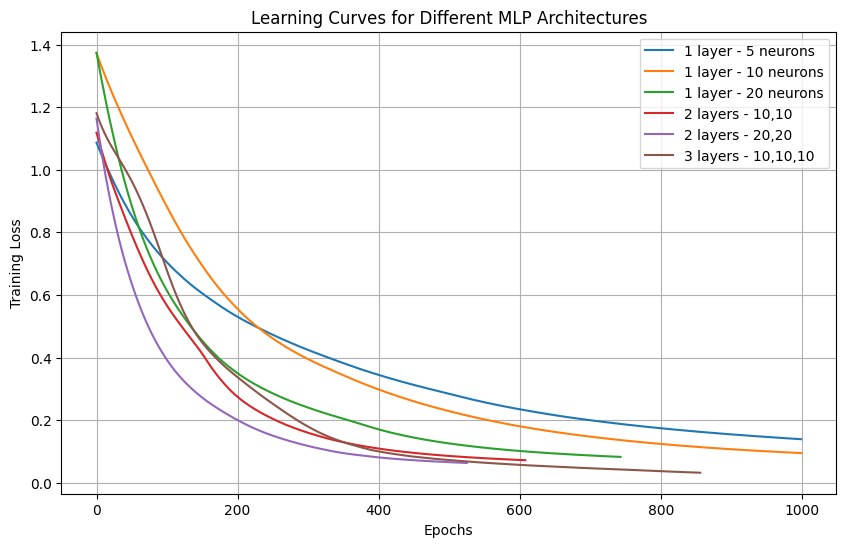

In [ ]:
plt.figure(figsize=(10, 6))

for name, result in results.items():
    plt.plot(result["loss_curve"], label=name)

plt.title("Learning Curves for Different MLP Architectures")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.grid()

plt.show()

1. How does increasing the number of layers or neurons affect the accuracy and learning curve?

In our experiments, all the tested MLP configurations achieved an accuracy of 1.0000 (100%) on the test set. Therefore, increasing the number of layers or neurons did not improve the test accuracy in this case. However, the number of epochs required for convergence changed between configurations. Some smaller networks required the full 1000 epochs, while the 2-layer network with 20 neurons in each layer converged in 526 epochs. The learning curves also show differences in the speed of convergence between the different architectures.

2. What configuration gives the best performance?

Since all configurations achieved 100% test accuracy, there is no single configuration with better test accuracy. However, considering convergence speed, the 2-layer network with 20 neurons in each layer (20, 20) performed efficiently because it achieved 100% accuracy in 526 epochs, which was the lowest number of epochs among the tested configurations

TASK 2 — Change the Learning Rate

Learning Rates

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

Train Different Learning Rates

In [ ]:
lr_results = {}

for lr in learning_rates:

    model = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        max_iter=1000,
        random_state=42,
        learning_rate_init=lr
    )

    model.fit(X_train_scaled, y_train)

    y_pred_lr = model.predict(X_test_scaled)

    accuracy_lr = accuracy_score(y_test, y_pred_lr)

    lr_results[lr] = {
        "model": model,
        "accuracy": accuracy_lr,
        "epochs": model.n_iter_,
        "loss_curve": model.loss_curve_
    }

    print(f"Learning Rate: {lr}")
    print(f"Accuracy: {accuracy_lr:.4f}")
    print(f"Epochs: {model.n_iter_}")
    print("-" * 40)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001
Accuracy: 0.7333
Epochs: 1000
----------------------------------------
Learning Rate: 0.001
Accuracy: 1.0000
Epochs: 609
----------------------------------------
Learning Rate: 0.01
Accuracy: 1.0000
Epochs: 157
----------------------------------------
Learning Rate: 0.1
Accuracy: 0.9556
Epochs: 159
----------------------------------------


Compare Learning Rates

In [ ]:
print("LEARNING RATE COMPARISON")
print("=" * 60)

for lr, result in lr_results.items():

    print(
        f"Learning Rate: {lr:<8} "
        f"Accuracy: {result['accuracy']:.4f}   "
        f"Epochs: {result['epochs']}"
    )

LEARNING RATE COMPARISON
Learning Rate: 0.0001   Accuracy: 0.7333   Epochs: 1000
Learning Rate: 0.001    Accuracy: 1.0000   Epochs: 609
Learning Rate: 0.01     Accuracy: 1.0000   Epochs: 157
Learning Rate: 0.1      Accuracy: 0.9556   Epochs: 159


Plot All Learning Rate Curves

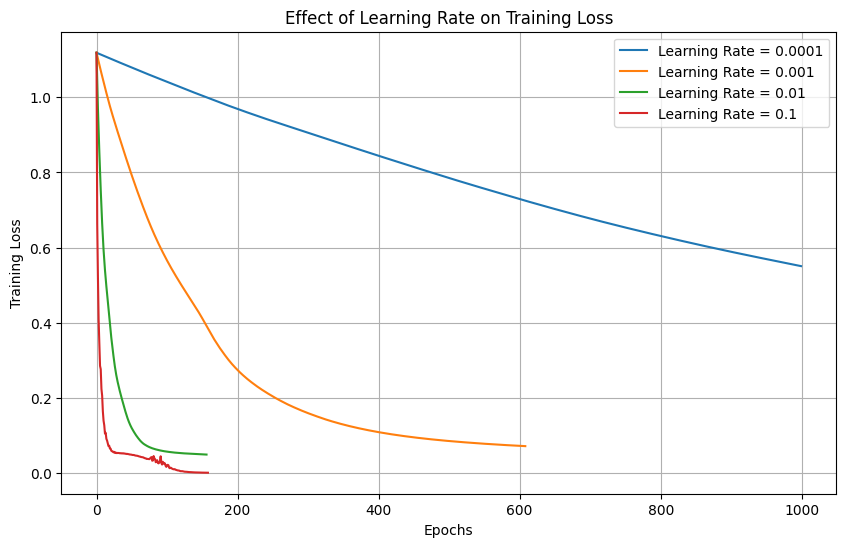

In [ ]:
plt.figure(figsize=(10, 6))

for lr, result in lr_results.items():
    plt.plot(
        result["loss_curve"],
        label=f"Learning Rate = {lr}"
    )

plt.title("Effect of Learning Rate on Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.grid()

plt.show()

Individual Curves

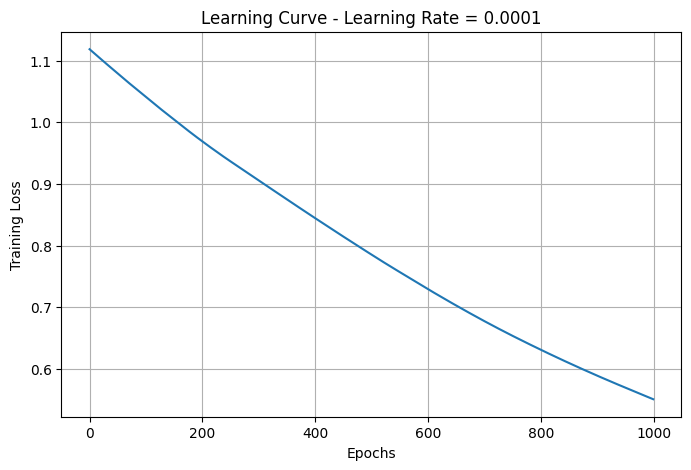

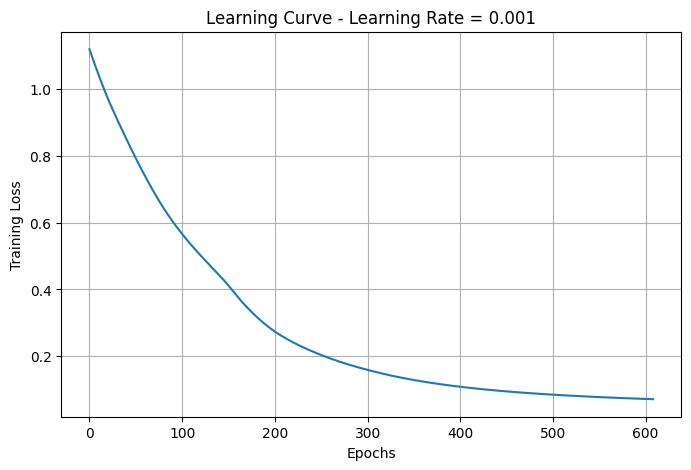

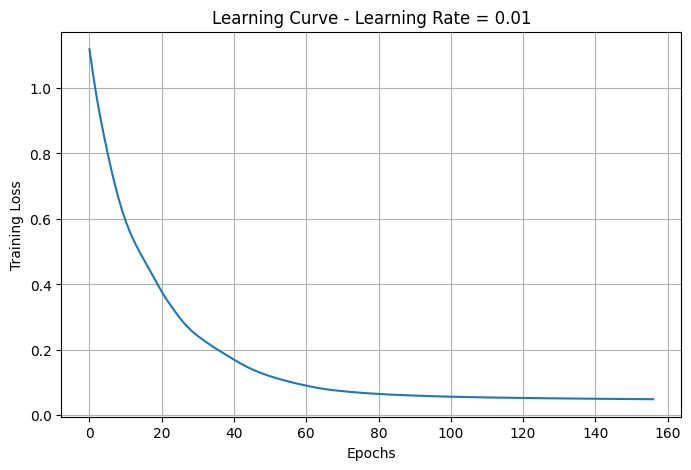

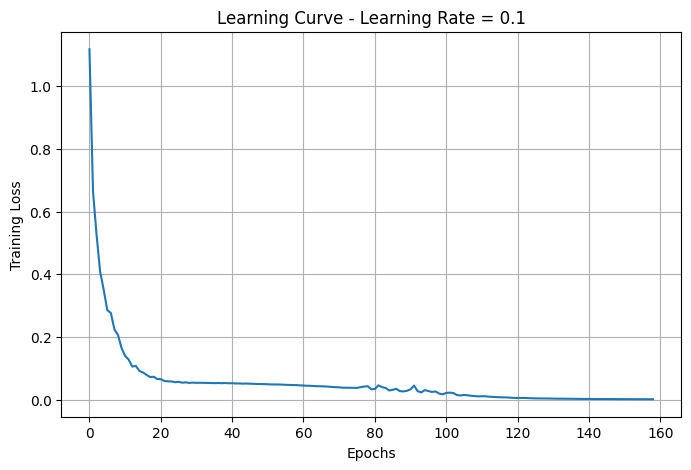

In [ ]:
for lr, result in lr_results.items():

    plt.figure(figsize=(8, 5))

    plt.plot(result["loss_curve"])

    plt.title(f"Learning Curve - Learning Rate = {lr}")
    plt.xlabel("Epochs")
    plt.ylabel("Training Loss")
    plt.grid()

    plt.show()

Automatically Find the Highest Accuracy

In [ ]:
best_lr = max(
    lr_results,
    key=lambda lr: lr_results[lr]["accuracy"]
)

print("Learning rate with highest test accuracy:", best_lr)
print(
    "Accuracy:",
    lr_results[best_lr]["accuracy"]
)
print(
    "Epochs:",
    lr_results[best_lr]["epochs"]
)

Learning rate with highest test accuracy: 0.001
Accuracy: 1.0
Epochs: 609


1. How does changing the learning rate affect the loss curve and the number of epochs?

Changing the learning rate had a clear effect on the convergence of the MLP. A very small learning rate of 0.0001 required the full 1000 epochs and achieved an accuracy of 73.33%. The learning rate of 0.001 achieved 100% accuracy in 609 epochs. Increasing the learning rate to 0.01 reduced the number of epochs to 157 while maintaining 100% accuracy. However, increasing it further to 0.1 resulted in 159 epochs but reduced the accuracy to 95.56%. Therefore, the learning rate affects both the speed of convergence and the model's performance.

2. What learning rate provides the best balance between convergence speed and model performance?

Based on our results, the learning rate of 0.01 provides the best balance among the tested values. It achieved 100% accuracy and converged in only 157 epochs, compared with 609 epochs for a learning rate of 0.001. Although 0.1 converged in a similar number of epochs, its accuracy decreased to 95.56%.

Therefore, 0.01 provided fast convergence while maintaining the highest test accuracy among the tested learning rates.